# Monte Carlo simulation-based model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 1 - PET/Code/Methods.py'>

In [23]:
def visualize_rays(source_x, slit_width_W, ux, uz, z_gap_1, z_gap_2):
    Z_gate_start, Z_gate_end = 36.0, 46.0
    Rscint = 35
    Z_scint = 100.0
    X_gate_left, X_gate_right = -slit_width_W / 2.0, slit_width_W / 2.0

    # Classification Masks
    mask_gap = ((z_gap_2 > Z_gate_end) & (z_gap_1 < 0)) | ((z_gap_2 > Z_gate_end) & (z_gap_1 < Z_gate_start))  # Through the gap
    mask_full = (z_gap_2 < 0) | (z_gap_1 > Z_gate_end) | ((z_gap_1 < Z_gate_start) & (z_gap_1 > 0) & (z_gap_2 < 0)) | ((z_gap_1 < Z_gate_start) & (z_gap_2 < Z_gate_start) & (z_gap_1 > 0))          # Entirely through lead (Front-to-Back)
    mask_side = ((z_gap_1 > Z_gate_start) & (z_gap_1 < Z_gate_end)) | ((z_gap_2 > Z_gate_start) & (z_gap_2 < Z_gate_end))
    # ^ mask for all rays that enter/exit at least one inside edge of a gate
    mask_both = (z_gap_1 > Z_gate_start) & (z_gap_2 < Z_gate_end)
    # ^mask for rays that enter and exit both gates

    # Plotting Gate Boundaries
    types = [
        (mask_gap, 'green', 'Air (Slit)'),
        (mask_full, 'red', 'Full Lead (Front-Back)'),
        (mask_side & ~mask_both, 'orange', 'Side Wall/Corner Clip'),
        (mask_both, 'purple', 'Both Gates')
    ]

    for mask, color, label in types:
        idx = np.where(mask)[0][:1000]
        for i in idx:
            z_vals = np.array([0, Z_scint])
            x_vals = source_x + (z_vals / uz[i]) * ux[i]
            plt.plot(x_vals, z_vals, color=color, alpha=0.4, linewidth=0.8)
        plt.plot([], [], color=color, label=label)

    plt.axhspan(Z_gate_start, Z_gate_end, xmin=0, xmax=0.5 + X_gate_left/80, color='gray', alpha=0.3,zorder=3)
    plt.axhspan(Z_gate_start, Z_gate_end, xmin=0.5 + X_gate_right/80, xmax=1, color='gray', alpha=0.3,zorder=3)
    plt.axhspan(ymin=99, ymax=100, xmin=0.5-Rscint/80, xmax=0.5+Rscint/80, color='black', alpha=0.7,zorder=3)

    plt.title(f"X-Z Projection of Rays (Source at x={source_x})")
    plt.xlabel("X Position (mm)")
    plt.ylabel("Z Depth (mm)")
    plt.xlim(-40, 40)
    plt.ylim(0, 100)
    plt.legend(loc='upper right')
    plt.savefig("./figures/VisualizedRays", dpi=300)
    plt.show()

In [34]:
def get_transmission_efficiency(
    source_x,
    slit_width_W,
    attenuation_len,
    n_rays=100000
):
    # --- Constants ---
    Z_gate_start = 36.0
    Z_gate_end = 46.0
    Z_scint = 100.0
    R_scint = 35.0
    X_gate_left = -slit_width_W / 2.0
    X_gate_right = slit_width_W / 2.0
    np.random.seed(0)

    phi = np.random.uniform(0, 2*np.pi, n_rays)
    costheta = np.random.uniform(0, 1, n_rays)
    sintheta = np.sqrt(1 - costheta**2)
    tantheta = sintheta/costheta

    ux = np.sin(phi) * costheta
    uy = np.sin(phi) * sintheta
    uz = np.cos(phi)
    tanphi = np.tan(phi)


    x_at_scint = source_x + Z_scint * tanphi
    y_at_scint = Z_scint * tanphi * sintheta # Project y similarly

    hit_mask = (x_at_scint**2 + y_at_scint**2) <= R_scint**2

    ux, uy, uz, costheta = ux[hit_mask], uy[hit_mask], uz[hit_mask], costheta[hit_mask]

    if len(uz) == 0: return 0.0

    m = np.where(np.abs(uz) < 1e-9,  np.infty, ux / uz)
    m = np.where(np.abs(m) < 1e-9, 1e-9, m)

    z_cross_left  = (X_gate_left - source_x) / m
    z_cross_right = (X_gate_right - source_x) / m
    z_gap_1 = np.minimum(z_cross_left, z_cross_right)
    z_gap_2 = np.maximum(z_cross_left, z_cross_right)

    mask_gap = ((z_gap_2 > Z_gate_end) & (z_gap_1 < 0)) | ((z_gap_2 > Z_gate_end) & (z_gap_1 < Z_gate_start))
    # ^ Through the gap
    mask_full = (z_gap_2 < 0) | (z_gap_1 > Z_gate_end) | ((z_gap_1 < Z_gate_start) & (z_gap_1 > 0) & (z_gap_2 < 0)) | ((z_gap_1 < Z_gate_start) & (z_gap_2 < Z_gate_start) & (z_gap_1 > 0))
    # ^ Entirely through lead (Front-to-Back)
    mask_side = ((z_gap_1 > Z_gate_start) & (z_gap_1 < Z_gate_end)) | ((z_gap_2 > Z_gate_start) & (z_gap_2 < Z_gate_end))
    # ^ mask for all rays that enter/exit at least one inside edge of a gate
    mask_both = (z_gap_1 > Z_gate_start) & (z_gap_2 < Z_gate_end)
    # ^mask for rays that enter and exit both gates

    air_start = np.maximum(z_gap_1, Z_gate_start)
    air_end   = np.minimum(z_gap_2, Z_gate_end)
    z_air_thick = np.maximum(0, air_end - air_start)
    # d_lead = ((Z_gate_end - Z_gate_start) - z_air_thick) / costheta
    d_lead = np.zeros_like(uz)

    d_lead = np.where(mask_gap,0, d_lead)
    d_lead = np.where(mask_full,(Z_gate_end - Z_gate_start)/costheta, d_lead)
    d_lead = np.where(mask_side | mask_both,(Z_gate_end - Z_gate_start - z_air_thick)/costheta, d_lead)
    # d_lead = np.where(mask_both,(Z_gate_end - Z_gate_start - z_air_thick)/costheta, d_lead)

    weights = np.exp(-d_lead / attenuation_len)
    normalizedWeight = np.sum(weights) / n_rays
    # visualize_rays(source_x, slit_width_W, ux, uz, z_gap_1, z_gap_2)
    return normalizedWeight

In [35]:
get_transmission_efficiency(10,slit_width_W=2,attenuation_len=5.6,n_rays=30000)

0.0014753006529299561

In [41]:
# --- usage ---

# Example: Scan the source position
x_scan = np.arange(-10, 10, 0.01)
transmission = []

for x in x_scan:
    # 3mm slit, ~5.6mm lambda (Lead 511 keV)
    val = get_transmission_efficiency(x, slit_width_W=2.0, attenuation_len=1, n_rays=50000)
    transmission.append(val)

reversed_transmission = np.flip(transmission)

In [57]:
A = 8000
Rscint = 35 # mm
Rsource = 1.1
x0 = 0
distanceStep = x_scan[1] - x_scan[0]
background = 0.0234 # times exposure time

# Signal_Modelled = A*(reversed_transmission * transmission) + background
Signal_Modelled = A*np.array(transmission)+ (background * 60)

xArr = x_scan
Xsource = np.arange(start=-Rsource + x0,stop=Rsource + x0,step=distanceStep)
sourceArr = m.sphereConvolve(Rsource, Xsource, x0)
sourceArr = sourceArr / max(sourceArr)

convolvedSignal = np.convolve(Signal_Modelled, sourceArr, mode='full')
convolvedX = np.arange(start=-len(convolvedSignal)/2, stop=len(convolvedSignal)/2, step=1) * distanceStep + x0
convolvedSignal = convolvedSignal + background

convolvedSignal = convolvedSignal * max(Signal_Modelled) / max(convolvedSignal)


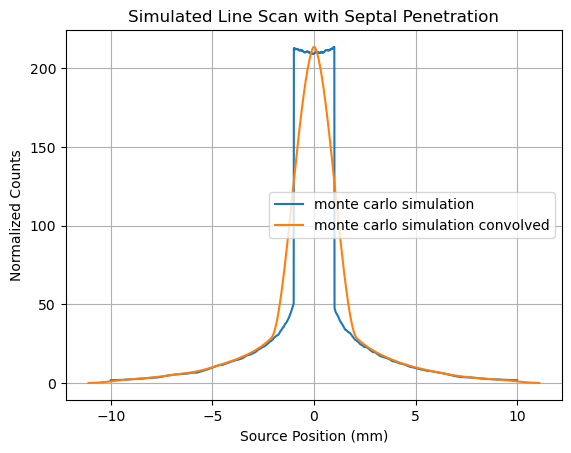

In [58]:
# print(len(x_scan))
# print(len(Signal_Modelled))


plt.plot(x_scan, Signal_Modelled, label="monte carlo simulation")
plt.plot(convolvedX, convolvedSignal, label="monte carlo simulation convolved")
plt.title("Simulated Line Scan with Septal Penetration")
plt.xlabel("Source Position (mm)")
plt.ylabel("Normalized Counts")
plt.legend()
plt.grid(True)
plt.show()

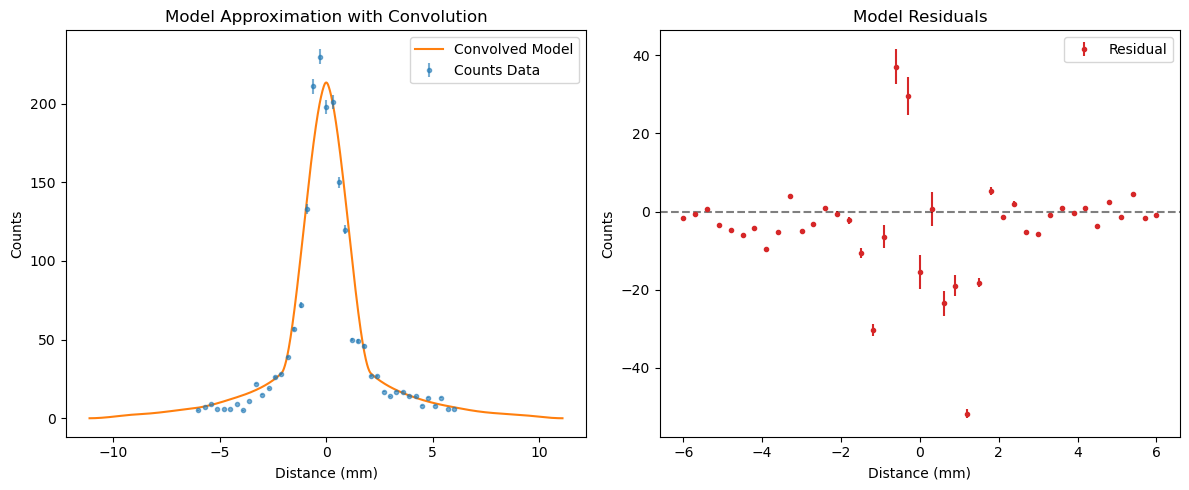

In [59]:
dist_array, counts_array, ucounts_array = m.readLineScan("./data/Lead Linescans - Feb 4/Feb 4, 2026, 3_25 PM, Scan1, 0_0 Deg, w-2mm.dat")

# print(max(convolvedSignal))

m.displayModelDataLinescan(convolvedX, convolvedSignal, dist_array, counts_array, ucounts_array, "Combined Convoluted Model+Residual - lead linescan.png")